In [3]:
print(sys.executable)

g:\Mi unidad\Tesis v1\mt\Scripts\python.exe


## ENTRENAMIENTO DE MODELOS EN BASE A NUESTRO DATASET PREPROCESADO ANTERIORMENTE
#### Dentro de este jupyter se presenta todo el proceso de entrenamiento de un nuevo modelo en base a los datos que recopilamos y preprocesamos en el notebook anterior. Este notebook presenta todo el proceso de entrenamiento, evaluación y ajuste fino para la clasificación de los paradigmas dentro de una señal EEG
##### Este notebook es una muestra simple de cómo poder usar la librería `Backend_DL`para un pipeline completo de formación de modelos de predicción de paradigmas EEG, con ayuda de ***EEGNET*** y *TensorFLOW* 

##### Los objetivos principales de esta librería son:

- Creación de un objeto para la preselección de los datos 
- Preselección de las clases para entrenar
- Selección de los canales a utilizar
- Creación de npz a formato compatible con entrenamiento de Keras 
- Separación de clases y undersampleo y balance de las mismas 
- Split de los datos de entrenamiento con estratificación en sujetos, sesiones o triales compatibles con el formato [MOABB](https://moabb.neurotechx.com/docs/index.html)
- Normalización de los datos para keras
- Entrenamiento general del modelo con definición de hiperparámetros 
- Aplicación de ajuste fino 
- Evaluación y métricas de los modelos

### 1) Establecer área de trabajo (Pueden ignorar esta primera celda y sólo importar la librería)

In [1]:
import os
import sys
import numpy as np

project_path = 'G:\\Mi unidad\\Tesis v1\\Movement_clasify' 
print(f"Ruta de trabajo actual: {project_path}")



os.chdir(project_path) #change directory B)
sys.path.append(project_path)


#Elegimos la ruta donde trabajaremos con colab
BASE_FOLDER = os.getcwd() #Ruta actual del proyecto

#Rutas donde tenemos demás recursos
scripts_path = os.path.join(BASE_FOLDER, 'scripts')
note_path = os.path.join(BASE_FOLDER, 'notebooks')
resources_path = os.path.join(BASE_FOLDER, 'Recursos')

#Asegurarnos de que todos existan
if os.path.exists(scripts_path): #Donde están nuestras librerían
    if scripts_path not in sys.path:
        sys.path.append(scripts_path)
        print(f"✅ Path agregado: {scripts_path}")
else: print(f"No encontrse encontró la carpeta en {scripts_path}")
if os.path.exists(note_path): #
    if note_path not in sys.path:
        sys.path.append(note_path)
        print(f"✅ Path agregado: {note_path}")
else: print(f"No encontrse encontró la carpeta en {note_path}")
if os.path.exists(resources_path):#Donde están nuestros datos
    if resources_path not in sys.path:
        sys.path.append(resources_path)
        print(f"✅ Path agregado: {resources_path}")
else: print(f"No encontrse encontró la carpeta en {resources_path}")

#Importamos nuestras librerías internas
import backend_DL_v2 as dl

Ruta de trabajo actual: G:\Mi unidad\Tesis v1\Movement_clasify
✅ Path agregado: G:\Mi unidad\Tesis v1\Movement_clasify\scripts
✅ Path agregado: G:\Mi unidad\Tesis v1\Movement_clasify\notebooks
✅ Path agregado: G:\Mi unidad\Tesis v1\Movement_clasify\Recursos


### 2) Creación de objeto y selección de canales, al crear del objeto se pueden especificar: 
- La selección de canales
- La posibilidad de undersamplear las clases mayoritarias por balance 
- Posibilidad de fusionar o no las clases imaginarias con las motoras

En el caso de este dataset, la distribución de clases quedaría de la siguiente manera: 
    "rest" -> 0

    "right_i" -> 1

    "left_i"->2

    "hands_i" -> 3

    "feet_i" -> 4

    "right_m" -> 5

    "left_m" -> 6

    "hands_m" -> 7
    
    "feet_m" -> 8

In [ ]:


"""            
            0: FULL           
            1: SOLO MOTOR (5 clases)
            2: SOLO IMAGINADO 5 CLASES
            3: 9 CLASES SIN FUSIÓN
            4: REST-IZQ-DER fusionado
            5: REST-MANOS-PIES fusionado
            6: REST-IZQ-DER SOLO MOTOR
            7: REST-MANOS-PIES SOLO MOTOR
            8: TODAS CLASES BINARIO (REST vs MOVIMIENTO)
            9: REST vs MOVIMIENTO SOLO MOTOR
            10: MANOS VS PIES, fusionado
            11: MANOS VS PIES, solo motor
            12: DERECHA vs IZQUIERDA, fusionado 
            13: DERECHA vs IZQUIERDA, solo motor
"""

#Probamos nuestro nuevo objeto
pick = 0
obj = dl.Selection(pick=pick, Debug=True)



### 3) Una vez creado el objeto, se puede establecer una ruta al dataset para ejecutar y a su vez se pueden elegir los canales que se quieren usar para el entrenamiento con el atributo "pick_ch"
(Recordatorio: debo crear una función de fet channels, pues ya existe el resume_dataset pero para evitar tantos datos)

In [24]:
path_dataset = "Recursos/7_ch/101_subs/eeg_dataset_0.00015rate.npz"
obj.load(path_dataset)
obj.pick_ch(["C3..", "C4..", "Cz.."])
print("y antes del pipeline:", np.unique(obj.y, return_counts=True))
#obj.resume_dataset(subs=True)


✔️ Dataset cargado desde: Recursos/7_ch/101_subs/eeg_dataset_0.00015rate.npz
✔ Canales seleccionados: ['C3..', 'C4..', 'Cz..']
Nuevo shape X: (166170, 3, 160)
y antes del pipeline: (array([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype=int32), array([82325, 10490, 10620, 10485, 10475, 10435, 10540, 10255, 10545]))


### 4) Una vez todos los argumentos listos, se puede usar el atributo "pipeline" para ejecutar todo lo pedido

In [25]:
obj.pipeline(undersample_rest=True)

# Debug inmediato
print("y único:", np.unique(obj.y))
print("conteos:", np.unique(obj.y, return_counts=True))
print("X shape:", obj.X.shape)



No se va a aplicar undersample!
✔ Aplicando pick: [0, 3, 4, 7, 8]. . . 
✔ Clases fusionadas semánticamente.
Clases finales: ['rest', 'hands', 'feet']
{np.int32(0): np.int64(82325), np.int32(1): np.int64(20740), np.int32(2): np.int64(21020)}
✔ Datos antes del undersampling en 0: 82325
Undersampling: clase 0 recortada de 82325 a 21020 muestras.
Datos después de undersampling - 0: 21020
y único: [0 1 2]
conteos: (array([0, 1, 2], dtype=int32), array([21020, 20740, 21020]))
X shape: (62780, 3, 160)


### 4.5) Opcionalmente, se puede usar el atributo "resume_data" para examinar los datos antes del entrenamiento

In [26]:
obj.resume_data()



X shape: (62780, 3, 160)
y shape: (62780,)
sub shape: (62780,)
trial shape: (62780,)
run shape: (62780,)
Número de clases: 3
Número de sujetos: 97

Clases:
   codigo nombre
0       0   rest
1       1  hands
2       2   feet

Conteo por clase:
0    21020
1    20740
2    21020
Name: count, dtype: int64


### 5) Con el método "pick_fine" se pueden separtar los datos en aquellos datos de entrenamiento y aquellos datos de ajuste fino 
(Recordatorio: debo hacer un atributo de get_model para aquellos que no quieran dividir el dataset)

In [27]:
data_model, data_fine = obj.pick_fine(7)

print("Distribución de clases en data_model:", np.unique(data_model.y, return_counts=True))
print("Distribución de clases en data_fine:", np.unique(data_fine.y, return_counts=True))

✔ Sujetos entrenamiento: [  1   2   3   4   5   6   8   9  10  11  12  14  15  16  18  19  20  21
  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39
  40  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58
  59  60  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79
  80  81  82  84  85  86  87  89  90  91  93  94  95  96  97  98  99 101
 102 103 105 106 107 108]
✔ Sujeto fine-tune: 7
Shape modelo: (62103, 3, 160)
Shape fine: (677, 3, 160)
Distribución de clases en data_model: (array([0, 1, 2], dtype=int32), array([20793, 20520, 20790]))
Distribución de clases en data_fine: (array([0, 1, 2], dtype=int32), array([227, 220, 230]))


### 6) Entrenamiento del modelo general con "eeg_train", se establecen las épocas, el modo de estratificación, así como el tamaño de la separación de los datos de entrenamiento y validación

In [28]:
modelo, history, mean, std, keras_split, info = dl.eeg_train(
    data_model, test_size=0.15, val_size=0.15, 
    mode="subject",
    epochs=60,
    debug=True
)

Modo de split: subject
Split por grupo:
  Train: 43288 muestras, grupos: [  2   3   4   6   8   9  10  16  18  20  21  23  24  25  27  28  29  31
  32  33  36  38  39  40  42  43  46  48  49  51  52  53  54  55  56  57
  59  60  64  65  66  67  68  69  70  71  73  74  78  79  80  82  84  85
  87  91  93  94  95  97  98 101 102 103 105 106 108]
  Val:   9063 muestras, grupos: [ 11  35  45  47  50  58  72  76  77  81  89  96  99 107]
  Test:  9752 muestras, grupos: [ 1  5 12 14 15 19 22 26 30 34 37 44 75 86 90]
Modo split: subject
X_train: (43288, 3, 160)
X_val: (9063, 3, 160)
X_test: (9752, 3, 160)
Antes de normalizar: (43288, 3, 160) Después de normalizar: (43288, 3, 160) Después de ajustar para Keras: (43288, 3, 160, 1)
Epoch 1/60


c:\Users\Josjuan\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1353/1353 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.3710 - loss: 1.0911 - val_accuracy: 0.3702 - val_loss: 1.0931
Epoch 2/60
1353/1353 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.3919 - loss: 1.0813 - val_accuracy: 0.3743 - val_loss: 1.0944
Epoch 3/60
1353/1353 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.4030 - loss: 1.0757 - val_accuracy: 0.3910 - val_loss: 1.0871
Epoch 4/60
1353/1353 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.4126 - loss: 1.0726 - val_accuracy: 0.3584 - val_loss: 1.0869
Epoch 5/60
1353/1353 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.4168 - loss: 1.0700 - val_accuracy: 0.3740 - val_loss: 1.0829
Epoch 6/60
1353/1353 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.4170 - loss: 1.0693 - val_accuracy: 0.3936 - val_loss: 1.0836
Epoch 7/60
1353/1353 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.4206 - loss: 1.0673 - val_accuracy: 0.3937 - val_loss: 1.0847
Epoch 8/60
1353/1353 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.4212 - loss: 1.0661 - val_accurac

##### Examinar modelo obtenido

305/305 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

=== Evaluación EEGNet ===
Clases (índice -> nombre):
  0: rest
  1: hands
  2: feet

Matriz de confusión (conteos):
[[ 900 1816  641]
 [ 423 2323  379]
 [ 482 1808  980]]

Reporte de clasificación:
              precision    recall  f1-score   support

        rest       0.50      0.27      0.35      3357
       hands       0.39      0.74      0.51      3125
        feet       0.49      0.30      0.37      3270

    accuracy                           0.43      9752
   macro avg       0.46      0.44      0.41      9752
weighted avg       0.46      0.43      0.41      9752



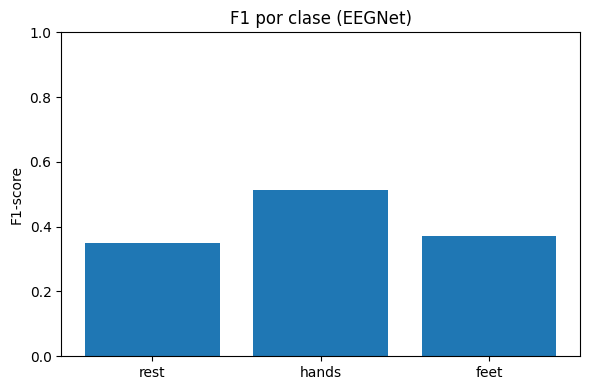

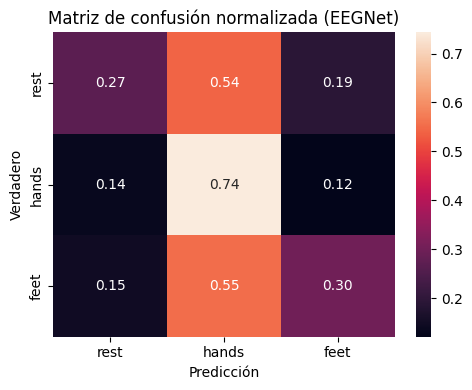

{'y_pred': array([1, 2, 1, ..., 1, 1, 1], shape=(9752,)),
 'cm': array([[ 900, 1816,  641],
        [ 423, 2323,  379],
        [ 482, 1808,  980]]),
 'cm_norm': array([[0.26809651, 0.54095919, 0.1909443 ],
        [0.13536   , 0.74336   , 0.12128   ],
        [0.14740061, 0.5529052 , 0.29969419]]),
 'precision': array([0.49861496, 0.39061712, 0.49      ]),
 'recall': array([0.26809651, 0.74336   , 0.29969419]),
 'f1': array([0.34870205, 0.51212522, 0.37191651])}

In [29]:
dl.evaluate(modelo, keras_split, obj.label_map)

In [ ]:
#Guardamos el modelo y sus parámetros de normalización
clases = np.unique(obj.pick)
path = f"Recursos/models/general/{len(np.unique(obj.sub))}_subjects/{clases}_trained_models_v1"
print(f"Guardando modelo en: {path}")

if not os.path.exists(path):
    os.makedirs(path)

dl.save_model(modelo, mean, std, path = path, name_model = f"Gmodel_{len(obj.X)}_{len(np.unique(obj.sub))}_3ch_{pick}.keras", name_params = f"EEGnet_general_{len(obj.X)}_{len(np.unique(obj.sub))}_3ch_{pick}.npz")


Guardando modelo en: Recursos/models/general/97_subjects/[0 3 4 7 8]_trained_models_v1


In [40]:
#Cargar modelo en caso de que ya tenegamos uno guardado
modelo, mean, std = dl.load_model(model_path = "Recursos/models/general/97_subjects/[None]_trained_models_v1/Gmodel_166170_97.keras", 
                                  params_path = "Recursos/models/general/97_subjects/[None]_trained_models_v1/EEGnet_general_166170_97.npz")


In [30]:
modelo_ft, histor_ft, mean_ft, std_ft, keras_split_ft = dl.eeg_fine(modelo, 
                                                        data_fine, mean = mean, std = std, test_size=0.15, val_size=0.15,
                                                        debug=True, epochs=150, lr=2e-4, batch_size=16, unfreeze_last_n=None)


Modo de split: trial
Split por grupo:
  Train: 456 muestras, grupos: [2132 2133 2134 2135 2136 2137 2139 2140 2143 2144 2145 2146 2149 2153
 2154 2155 2156 2159 2160 2161 2166 2168 2170 2172 2174 2176 2178 2182
 2184 2186 2188 2190 2193 2195 2196 2197 2198 2199 2200 2201 2202 2203
 2205 2207 2208 2209 2211 2212 2213 2215 2216 2222 2223 2224 2226 2228
 2229 2230 2232 2233 2235 2238 2240 2241 2242 2243 2244 2245 2247 2249
 2252 2254 2258 2262 2264 2266 2268 2270 2274 2286 2288 2306 2308 2310
 2316 2320 2322 2336 2338 2340 2342 2344 2346 2350 2352 2354 2360 2362
 2366 2372 2373 2374 2375 2377 2380 2381 2382 2383 2384 2386 2387 2388
 2390 2391 2392 2393 2394 2395 2397 2398 2400 2401 2403 2404 2406 2407
 2408 2409 2410 2411 2413 2414 2419 2420 2421 2424 2426 2430 2431 2432
 2440 2442 2446 2448 2456 2460 2462 2463 2464 2467 2468 2469 2470 2472
 2474 2477 2479 2480 2482 2483 2484 2485 2486 2488 2490 2491]
  Val:   109 muestras, grupos: [2141 2142 2147 2158 2194 2204 2219 2221 2237 2246 2248 2

Distribución de train (array([0, 1, 2], dtype=int32), array([161, 145, 150]))
Distribución de validation (array([0, 1, 2], dtype=int32), array([39, 40, 30]))
Distribución de test (array([0, 1, 2], dtype=int32), array([27, 35, 50]))
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

=== Evaluación EEGNet ===
Clases (índice -> nombre):
  0: rest
  1: hands
  2: feet

Matriz de confusión (conteos):
[[21  2  4]
 [ 1 34  0]
 [ 7 14 29]]

Reporte de clasificación:
              precision    recall  f1-score   support

        rest       0.72      0.78      0.75        27
       hands       0.68      0.97      0.80        35
        feet       0.88      0.58      0.70        50

    accuracy                           0.75       112
   macro avg       0.76      0.78      0.75       112
weighted avg       0.78      0.75      0.74       112



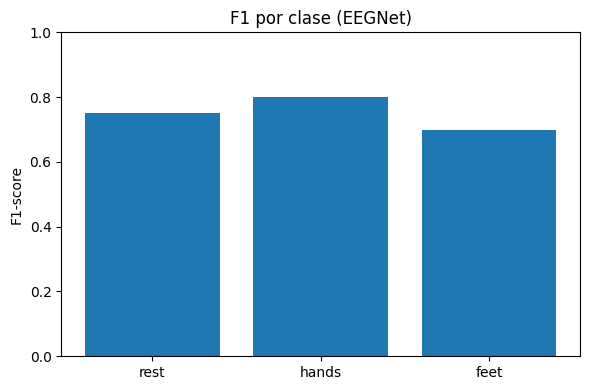

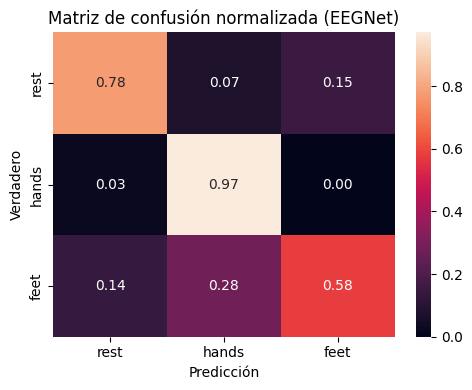

{'y_pred': array([2, 2, 2, 1, 0, 1, 0, 2, 1, 1, 2, 1, 2, 0, 0, 0, 0, 0, 0, 1, 0, 1,
        0, 0, 2, 2, 2, 1, 1, 1, 1, 2, 0, 1, 0, 0, 1, 1, 2, 1, 1, 2, 1, 2,
        2, 2, 0, 0, 1, 2, 2, 0, 0, 2, 1, 0, 0, 1, 1, 2, 0, 1, 1, 2, 1, 2,
        2, 1, 2, 1, 2, 1, 2, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 2, 1, 1,
        2, 2, 0, 1, 1, 0, 1, 1, 0, 1, 1, 2, 1, 0, 1, 0, 2, 1, 1, 2, 1, 2,
        2, 1]),
 'cm': array([[21,  2,  4],
        [ 1, 34,  0],
        [ 7, 14, 29]]),
 'cm_norm': array([[0.77777778, 0.07407407, 0.14814815],
        [0.02857143, 0.97142857, 0.        ],
        [0.14      , 0.28      , 0.58      ]]),
 'precision': array([0.72413793, 0.68      , 0.87878788]),
 'recall': array([0.77777778, 0.97142857, 0.58      ]),
 'f1': array([0.75      , 0.8       , 0.69879518])}

In [31]:
print("Distribución de train", np.unique(keras_split_ft.y.train, return_counts=True))
print("Distribución de validation", np.unique(keras_split_ft.y.val, return_counts=True))
print("Distribución de test", np.unique(keras_split_ft.y.test, return_counts=True))
dl.evaluate(modelo_ft, keras_split_ft, obj.label_map)

In [ ]:

path_f = f"Recursos/models/fined/{len(np.unique(obj.sub))}_subjects/{clases}_finned_model_v1"
print(f"Guardando modelo en: {path_f}")

if not os.path.exists(path_f):
    os.makedirs(path_f)

dl.save_model(modelo_ft, mean_ft, std_ft, path = path_f, name_model = f"Fmodel_{len(obj.X)}_{len(np.unique(obj.sub))}_3ch_{pick}.keras", name_params = f"EEGnet_fined_{len(obj.X)}_{len(np.unique(obj.sub))}_3ch_{pick}.npz")

Guardando modelo en: Recursos/models/fined/97_subjects/[0 3 4 7 8]_finned_model_v1
